---
categories:
- PPEC
- Ensino
- Estatística
date: 2023-03-16
description: Aula 3 - Notebook sobre estimação de parâmetros 
image: Atividade_Estimativa_de_parametros.png
title: "Estimação de parâmetros"
---

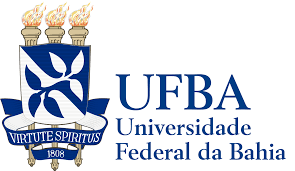


#          PPEC0039 - ESTATÍSTICA E PLANEJAMENTO DE EXPERIMENTOS

          DISCENTE: WELKENS OLIVEIRA
          EQUIPE: OUTLIERS
          TEMA: ESTIMAÇÃO DE PARÂMETROS

# INTRODUÇÃO

De acordo com o Murray Spiegel em sua obra intitulada "Estatística", a teoria da amostragem é o estudo das relações existentes entre uma população e as amostras obtidas dela.

Por esse motivo, é muito útil no dia a dia,o uso de técnicas que permitam a estimação de grandezas desconhecidas da população, tais como a média e variância por meio dos parâmetros correspondetes das amostras.

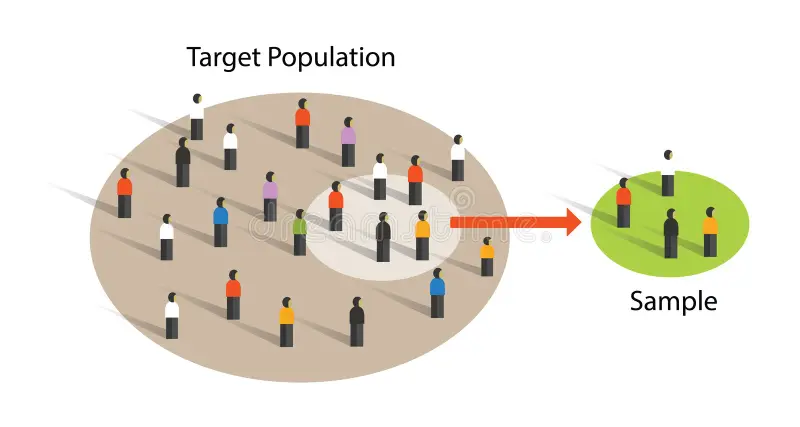

# DISTRIBUIÇÕES AMOSTRAIS

A distribuição amostral pode ser entendida como todas as amostras possíveis de tamanho N que podem ser retiradas de uma população dada. Para cada amostra podemos encontrar uma grandeza estatística como a média (**distribuição amostral da média**), ou o desvio padrão (**distribuição amostral do desvio padraão**).

# ESTIMAÇÃO DE PARÂMETROS NA GEOTECNIA


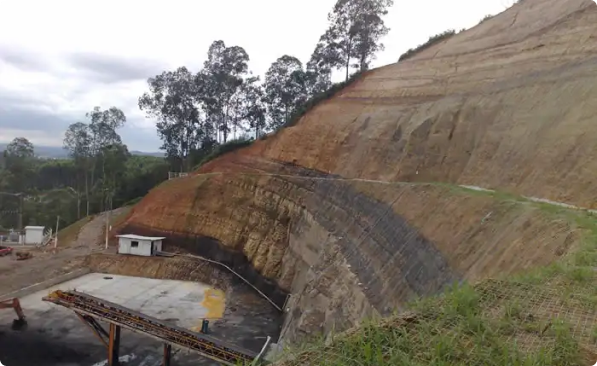

# EXERCÍCIO ILUSTRATIVO DE OBTENÇÃO DE PARÂMETROS

**Contextualização:** Na prática geotécnica é comum, em qualquer projeto ou laudo geotécnico solicitar a análise do solo. Essa análise pode ser feita por método diretos (coletas de amostras) ou indiretas (medidas obtidas por aparelhos geofísicos). Acontece que a coleta de amostras, bem como os ensaios de laboratório são dependentes do custo, portanto quanto maior a quantidade de amostras, maior o custo. Por esse motivo, é corriqueiro a coleta de algumas amostras e com base nessas amostras teorizar o comportamento do solo como um todo dentro daquele contexto específico.

**Problema:** Foi solicitado a turma 2026 na disciplina de Geotecnia Ambiental a obtenção dos parâmetros c (coesão do solo), 𝜙 (ângulo de atrito) e seus respectivos desvios-padrão de 12 amostras de uma barragem de rejeitos para simulação computacional do Fator de risco da barragem(FS). Os **parâmetros de resistência do solo (c e 𝜙)** são extremamente importantes para a previsão do comportamento do solo quando carregado em situações extremas. Foram dados os resultados de ensaios triaxiais contendo medidas de tensões desviadoras versus tensões cisalhantes, com base num ajuste (regressão linear) é possível obter os parâmetros de média e desvio padrão dos parâmetros do solo.

**Abaixo segue um código para calcular os Parâmetros do solo.**

ANÁLISE GEOTÉCNICA - ENSAIOS DE CISALHAMENTO
 σz      τ
 50  33.60
 50  32.62
 50  32.68
 50  35.00
100  68.11
100  69.16
100  69.22
100  66.26
200 134.41
200 137.16
200 137.05
200 135.92


1. ESTATÍSTICAS DESCRITIVAS POR NÍVEL DE TENSÃO
------------------------------------------------------------

σz = 50 kPa:
  Média: 33.48 kPa
  Desvio padrão: 1.11 kPa
  Coef. variação: 3.32%
  Valores: [33.6  32.62 32.68 35.  ]

σz = 100 kPa:
  Média: 68.19 kPa
  Desvio padrão: 1.38 kPa
  Coef. variação: 2.03%
  Valores: [68.11 69.16 69.22 66.26]

σz = 200 kPa:
  Média: 136.13 kPa
  Desvio padrão: 1.28 kPa
  Coef. variação: 0.94%
  Valores: [134.41 137.16 137.05 135.92]


2. PARÂMETROS DE RESISTÊNCIA (MOHR-COULOMB)
------------------------------------------------------------
Coesão (c) = -0.50 kPa
Ângulo de atrito (φ) = 34.36°
tan(φ) = 0.6837
Coeficiente de correlação (R) = 0.9997
R² = 0.9993


3. ANÁLISE DOS RESÍDUOS (VERIFICAÇÃO DA DISTRIBUIÇÃO NORMAL)
--------------------------------------------

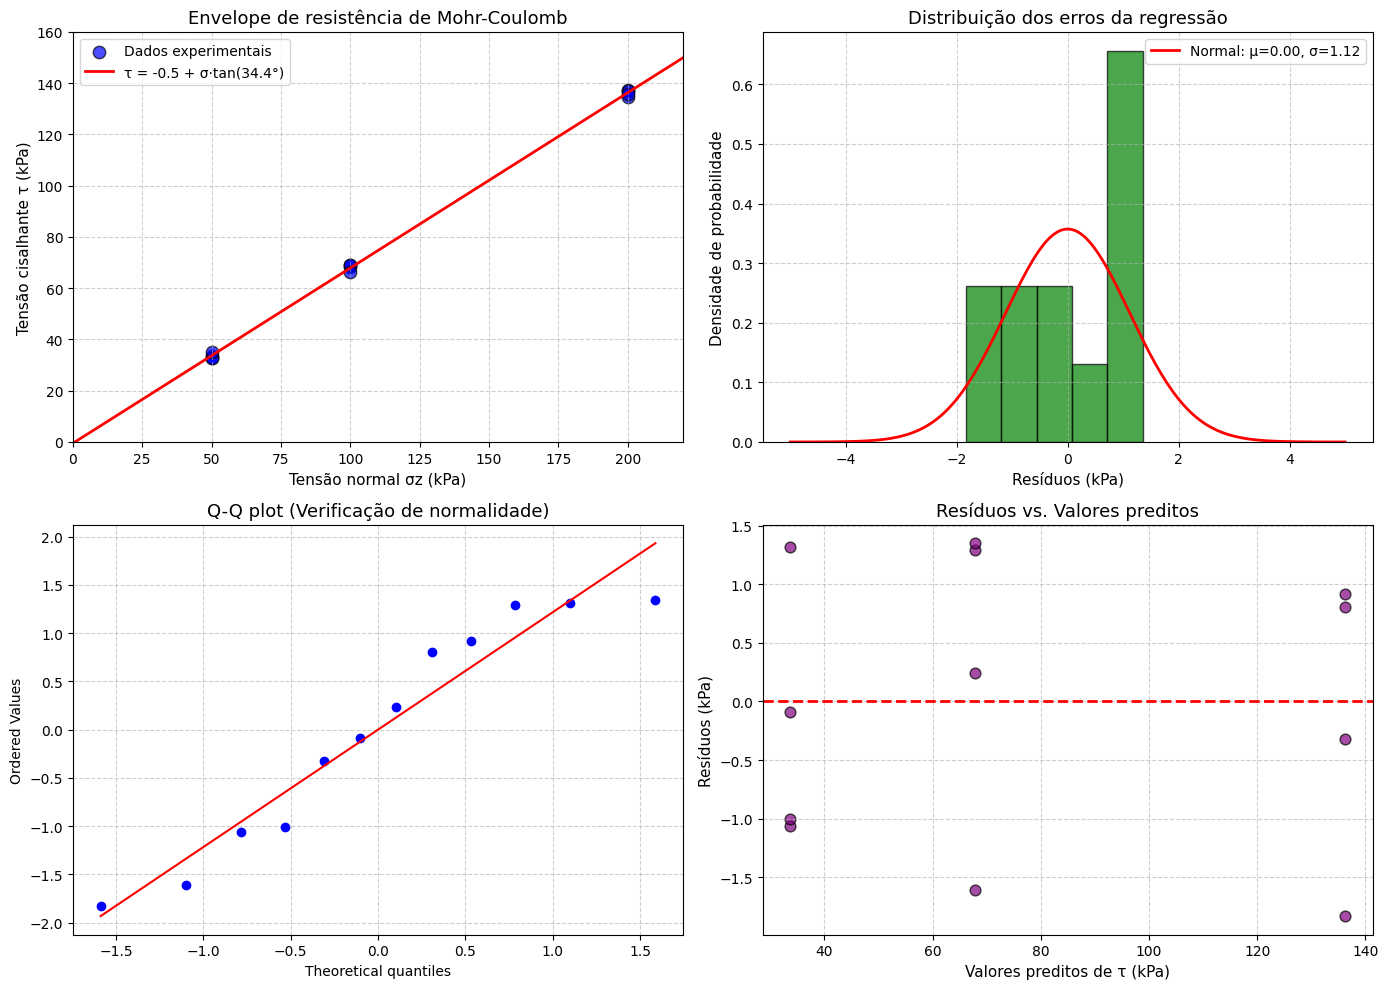



4. APLICAÇÃO PRÁTICA - PROBABILIDADE DE FALHA
------------------------------------------------------------
Para σz aplicado = 150 kPa:
  Resistência média prevista: 102.06 kPa
  Desvio padrão da resistência: 1.12 kPa

Cenário 1 - τ aplicado = 120 kPa:
  Probabilidade de falha (τ_resistência < τ_aplicado): 1.0000 (100.00%)

Cenário 2 - τ aplicado = 140 kPa:
  Probabilidade de falha: 1.0000 (100.00%)

Cenário 3 - Para probabilidade de falha de 5%:
  Tensão cisalhante aplicada crítica: 100.22 kPa
  Fator de segurança correspondente: 1.02


5. SIMULAÇÃO DE MONTE CARLO (10000 amostras)
------------------------------------------------------------
σz aplicado = 150 kPa, τ aplicado = 130 kPa
Probabilidade de falha (Monte Carlo): 1.0000 (100.00%)
Intervalo de confiança 95%: 1.0000 a 1.0000


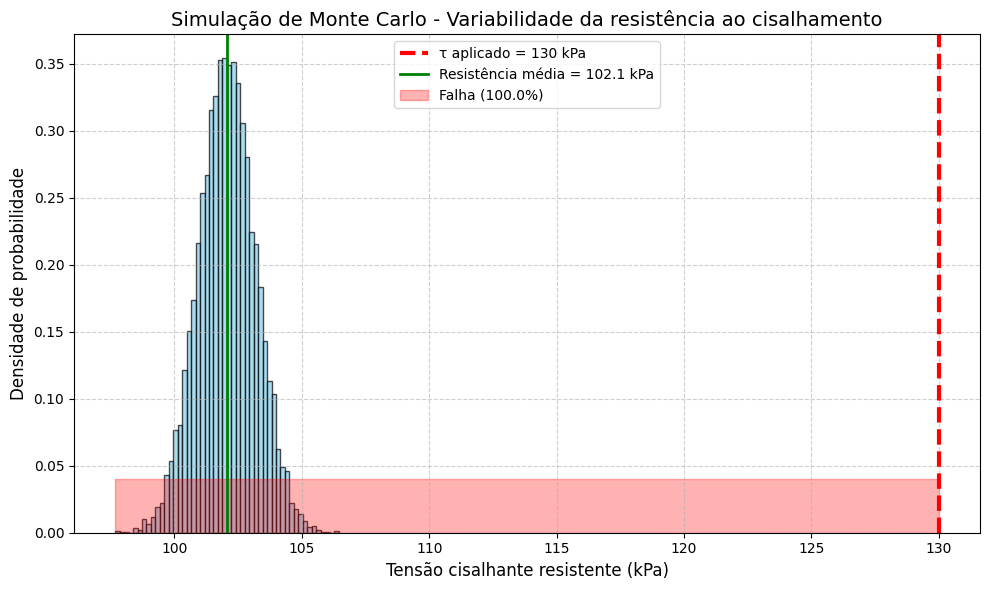


CONCLUSÕES GEOTÉCNICAS
✓ Solo com coesão de -0.5 kPa e ângulo de atrito de 34.4°
✓ Coeficiente de variação da resistência: 1.09%
✓ A análise probabilística é essencial para projetos seguros e econômicos


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Seus dados
dados = {
    'σz': [50, 50, 50, 50, 100, 100, 100, 100, 200, 200, 200, 200],
    'τ': [33.60, 32.62, 32.68, 35.00, 68.11, 69.16, 69.22, 66.26,
          134.41, 137.16, 137.05, 135.92]
}

df = pd.DataFrame(dados)

print("=" * 60)
print("ANÁLISE GEOTÉCNICA - ENSAIOS DE CISALHAMENTO")
print("=" * 60)
print(df.to_string(index=False))
print()

# 1. Estatísticas descritivas por nível de tensão
print("\n1. ESTATÍSTICAS DESCRITIVAS POR NÍVEL DE TENSÃO")
print("-" * 60)
for sigma in sorted(df['σz'].unique()):
    subset = df[df['σz'] == sigma]['τ']
    print(f"\nσz = {sigma} kPa:")
    print(f"  Média: {subset.mean():.2f} kPa")
    print(f"  Desvio padrão: {subset.std():.2f} kPa")
    print(f"  Coef. variação: {subset.std()/subset.mean()*100:.2f}%")
    print(f"  Valores: {subset.values}")

# 2. Regressão linear para obter c e φ (Mohr-Coulomb)
# τ = c + σ * tan(φ)  =>  y = a + b*x
# onde: y = τ, x = σz, a = c, b = tan(φ)

x = df['σz'].values
y = df['τ'].values

# Regressão linear (considerando todos os pontos)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

coesao = intercept  # c (kPa)
phi_rad = np.arctan(slope)  # φ em radianos
phi_graus = np.degrees(phi_rad)  # φ em graus

print("\n\n2. PARÂMETROS DE RESISTÊNCIA (MOHR-COULOMB)")
print("-" * 60)
print(f"Coesão (c) = {coesao:.2f} kPa")
print(f"Ângulo de atrito (φ) = {phi_graus:.2f}°")
print(f"tan(φ) = {slope:.4f}")
print(f"Coeficiente de correlação (R) = {r_value:.4f}")
print(f"R² = {r_value**2:.4f}")

# 3. Análise dos resíduos (erros da regressão)
residuos = y - (intercept + slope * x)

print("\n\n3. ANÁLISE DOS RESÍDUOS (VERIFICAÇÃO DA DISTRIBUIÇÃO NORMAL)")
print("-" * 60)
print(f"Média dos resíduos: {np.mean(residuos):.4f} kPa")
print(f"Desvio padrão dos resíduos: {np.std(residuos):.4f} kPa")

# Teste de normalidade de Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"Teste de Shapiro-Wilk: estatística = {shapiro_stat:.4f}, p-valor = {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("✓ Os resíduos seguem distribuição normal (p > 0.05)")
else:
    print("✗ Os resíduos NÃO seguem distribuição normal (p ≤ 0.05)")

# 4. Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Pontos experimentais + reta de regressão
ax1 = axes[0, 0]
ax1.scatter(x, y, color='blue', s=80, alpha=0.7, edgecolors='black', label='Dados experimentais')
x_line = np.array([0, 250])
y_line = intercept + slope * x_line
ax1.plot(x_line, y_line, 'r-', linewidth=2, label=f'τ = {coesao:.1f} + σ·tan({phi_graus:.1f}°)')
ax1.set_xlabel('Tensão normal σz (kPa)', fontsize=11)
ax1.set_ylabel('Tensão cisalhante τ (kPa)', fontsize=11)
ax1.set_title('Envelope de resistência de Mohr-Coulomb', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()
ax1.set_xlim(0, 220)
ax1.set_ylim(0, 160)

# Gráfico 2: Distribuição dos resíduos
ax2 = axes[0, 1]
ax2.hist(residuos, bins=5, density=True, alpha=0.7, color='green', edgecolor='black')
x_res = np.linspace(-5, 5, 200)
mu_res, std_res = np.mean(residuos), np.std(residuos)
ax2.plot(x_res, stats.norm.pdf(x_res, mu_res, std_res), 'r-', linewidth=2,
         label=f'Normal: μ={mu_res:.2f}, σ={std_res:.2f}')
ax2.set_xlabel('Resíduos (kPa)', fontsize=11)
ax2.set_ylabel('Densidade de probabilidade', fontsize=11)
ax2.set_title('Distribuição dos erros da regressão', fontsize=13)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Q-Q plot para verificar normalidade
ax3 = axes[1, 0]
stats.probplot(residuos, dist="norm", plot=ax3)
ax3.set_title('Q-Q plot (Verificação de normalidade)', fontsize=13)
ax3.grid(True, linestyle='--', alpha=0.6)

# Gráfico 4: Valores preditos vs resíduos
ax4 = axes[1, 1]
y_pred = intercept + slope * x
ax4.scatter(y_pred, residuos, color='purple', s=60, alpha=0.7, edgecolors='black')
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Valores preditos de τ (kPa)', fontsize=11)
ax4.set_ylabel('Resíduos (kPa)', fontsize=11)
ax4.set_title('Resíduos vs. Valores preditos', fontsize=13)
ax4.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 5. APLICAÇÃO PRÁTICA: Probabilidade de falha
print("\n\n4. APLICAÇÃO PRÁTICA - PROBABILIDADE DE FALHA")
print("-" * 60)

# Para uma tensão normal aplicada de 150 kPa
sigma_aplicado = 150  # kPa
tau_resistencia_media = coesao + slope * sigma_aplicado
desvio_residuos = np.std(residuos)

print(f"Para σz aplicado = {sigma_aplicado} kPa:")
print(f"  Resistência média prevista: {tau_resistencia_media:.2f} kPa")
print(f"  Desvio padrão da resistência: {desvio_residuos:.2f} kPa")

# Cenário 1: Tensão cisalhante aplicada = 120 kPa
tau_aplicado = 120
prob_falha = stats.norm.cdf(tau_aplicado, tau_resistencia_media, desvio_residuos)
print(f"\nCenário 1 - τ aplicado = {tau_aplicado} kPa:")
print(f"  Probabilidade de falha (τ_resistência < τ_aplicado): {prob_falha:.4f} ({prob_falha*100:.2f}%)")

# Cenário 2: Tensão cisalhante aplicada = 140 kPa
tau_aplicado = 140
prob_falha = stats.norm.cdf(tau_aplicado, tau_resistencia_media, desvio_residuos)
print(f"\nCenário 2 - τ aplicado = {tau_aplicado} kPa:")
print(f"  Probabilidade de falha: {prob_falha:.4f} ({prob_falha*100:.2f}%)")

# Cenário 3: Qual τ aplicado resulta em 5% de probabilidade de falha?
prob_alvo = 0.05
tau_critico = stats.norm.ppf(prob_alvo, tau_resistencia_media, desvio_residuos)
print(f"\nCenário 3 - Para probabilidade de falha de 5%:")
print(f"  Tensão cisalhante aplicada crítica: {tau_critico:.2f} kPa")
print(f"  Fator de segurança correspondente: {tau_resistencia_media/tau_critico:.2f}")

# 6. Simulação de Monte Carlo
print("\n\n5. SIMULAÇÃO DE MONTE CARLO (10000 amostras)")
print("-" * 60)

np.random.seed(42)
n_simulacoes = 10000
sigma_aplicado = 150
tau_aplicado = 130

# Gera resistências considerando a variabilidade
tau_resistencia_sim = coesao + slope * sigma_aplicado + np.random.normal(0, desvio_residuos, n_simulacoes)

# Calcula probabilidade de falha
falhas = np.sum(tau_resistencia_sim < tau_aplicado)
pf_mc = falhas / n_simulacoes

print(f"σz aplicado = {sigma_aplicado} kPa, τ aplicado = {tau_aplicado} kPa")
print(f"Probabilidade de falha (Monte Carlo): {pf_mc:.4f} ({pf_mc*100:.2f}%)")
print(f"Intervalo de confiança 95%: {pf_mc - 1.96*np.sqrt(pf_mc*(1-pf_mc)/n_simulacoes):.4f} a "
      f"{pf_mc + 1.96*np.sqrt(pf_mc*(1-pf_mc)/n_simulacoes):.4f}")

# Histograma da simulação
fig2, ax = plt.subplots(figsize=(10, 6))
ax.hist(tau_resistencia_sim, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(tau_aplicado, color='red', linewidth=3, linestyle='--', label=f'τ aplicado = {tau_aplicado} kPa')
ax.axvline(tau_resistencia_media, color='green', linewidth=2, linestyle='-', label=f'Resistência média = {tau_resistencia_media:.1f} kPa')
ax.fill_between([tau_resistencia_sim.min(), tau_aplicado], 0, 0.04, alpha=0.3, color='red', label=f'Falha ({pf_mc*100:.1f}%)')
ax.set_xlabel('Tensão cisalhante resistente (kPa)', fontsize=12)
ax.set_ylabel('Densidade de probabilidade', fontsize=12)
ax.set_title('Simulação de Monte Carlo - Variabilidade da resistência ao cisalhamento', fontsize=14)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("CONCLUSÕES GEOTÉCNICAS")
print("=" * 60)
print(f"✓ Solo com coesão de {coesao:.1f} kPa e ângulo de atrito de {phi_graus:.1f}°")
print(f"✓ Coeficiente de variação da resistência: {desvio_residuos/tau_resistencia_media*100:.2f}%")
print(f"✓ A análise probabilística é essencial para projetos seguros e econômicos")